In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, mean_absolute_error,  mean_absolute_percentage_error, r2_score
from kmodes.kmodes import KModes
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [3]:
ruta_csv = '../data/processed/Saber11_limpio.csv'
df = pd.read_csv(ruta_csv, sep=';')
df.head()

,periodo,cole_area_ubicacion,cole_caracter,cole_jornada,cole_mcpio_ubicacion,cole_naturaleza,estu_dedicacioninternet,estu_dedicacionlecturadiaria,estu_genero,estu_horassemanatrabaja,...,fami_tieneserviciotv,fami_trabajolabormadre,fami_trabajolaborpadre,punt_c_naturales,punt_global,punt_ingles,punt_lectura_critica,punt_matematicas,punt_sociales_ciudadanas,Año
0,20222,rural,tecnicoacademico,noche,cali,oficial,30minutosomenos,entre1y2horas,m,0,...,si,trabajacomopersonaldelimpiezamantenimientosegu...,noaplica,32,203,50.0,47,42,38,2022
1,20222,urbano,tecnico,completa,cali,nooficial,entre1y3horas,noleoporentretenimiento,m,0,...,si,nosabe,trabajaporcuentapropiaporejemploplomeroelectri...,44,224,52.0,48,47,38,2022
2,20222,urbano,academico,unica,cali,oficial,entre1y3horas,noleoporentretenimiento,f,0,...,si,trabajacomopersonaldelimpiezamantenimientosegu...,trabajaporcuentapropiaporejemploplomeroelectri...,43,223,35.0,53,46,40,2022
3,20222,urbano,tecnicoacademico,tarde,cali,nooficial,entre30y60minutos,30minutosomenos,f,0,...,si,noaplica,noaplica,46,235,37.0,48,49,48,2022
4,20222,rural,tecnicoacademico,manana,palmira,oficial,masde3horas,entre30y60minutos,f,0,...,si,tieneuntrabajodetipoauxiliaradministrativopore...,esduenodeunnegociopequenotienepocosempleadoson...,58,287,49.0,62,57,55,2022


In [22]:
df.columns

Index(['periodo', 'cole_area_ubicacion', 'cole_caracter', 'cole_jornada',
       'cole_mcpio_ubicacion', 'cole_naturaleza', 'estu_dedicacioninternet',
       'estu_dedicacionlecturadiaria', 'estu_genero',
       'estu_horassemanatrabaja', 'estu_mcpio_reside',
       'fami_comecarnepescadohuevo', 'fami_comecerealfrutoslegumbre',
       'fami_comelechederivados', 'fami_cuartoshogar', 'fami_educacionmadre',
       'fami_educacionpadre', 'fami_estratovivienda', 'fami_numlibros',
       'fami_personashogar', 'fami_situacioneconomica', 'fami_tieneautomovil',
       'fami_tienecomputador', 'fami_tieneconsolavideojuegos',
       'fami_tienehornomicroogas', 'fami_tieneinternet', 'fami_tienelavadora',
       'fami_tienemotocicleta', 'fami_tieneserviciotv',
       'fami_trabajolabormadre', 'fami_trabajolaborpadre', 'punt_global',
       'Año'],
      dtype='str')

In [21]:
# Lista de columnas a eliminar: el puntaje global + los puntajes de las otras materias
columnas_a_excluir = [
    'punt_c_naturales', 
    'punt_ingles', 
    'punt_lectura_critica', 
    'punt_matematicas', 
    'punt_sociales_ciudadanas'
]

# Sobrescribimos df excluyendo esas columnas
df = df.drop(columns=[col for col in columnas_a_excluir if col in df.columns])

print("¡DataFrame sobrescrito con éxito!")
print(f"Nuevas dimensiones de df (filas, columnas): {df.shape}")
print("Columnas restantes que usarás como predictoras (X):")
print(df.columns.tolist())

¡DataFrame sobrescrito con éxito!
Nuevas dimensiones de df (filas, columnas): (169004, 33)
Columnas restantes que usarás como predictoras (X):
['periodo', 'cole_area_ubicacion', 'cole_caracter', 'cole_jornada', 'cole_mcpio_ubicacion', 'cole_naturaleza', 'estu_dedicacioninternet', 'estu_dedicacionlecturadiaria', 'estu_genero', 'estu_horassemanatrabaja', 'estu_mcpio_reside', 'fami_comecarnepescadohuevo', 'fami_comecerealfrutoslegumbre', 'fami_comelechederivados', 'fami_cuartoshogar', 'fami_educacionmadre', 'fami_educacionpadre', 'fami_estratovivienda', 'fami_numlibros', 'fami_personashogar', 'fami_situacioneconomica', 'fami_tieneautomovil', 'fami_tienecomputador', 'fami_tieneconsolavideojuegos', 'fami_tienehornomicroogas', 'fami_tieneinternet', 'fami_tienelavadora', 'fami_tienemotocicleta', 'fami_tieneserviciotv', 'fami_trabajolabormadre', 'fami_trabajolaborpadre', 'punt_global', 'Año']


In [23]:
df.shape

(169004, 33)

#K-modes

In [4]:
# Variable objetivo
y = df['punt_global']

# Variables independientes
X = df.drop(columns=['punt_global']).astype(str)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
 

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
 

In [40]:
 #---------------------------------------------------------------
# 1. Modelo: K-Modes -> promedio de y por cluster
# ---------------------------------------------------------------
class KModesRegressor:
    def __init__(self, n_clusters=5, init="Huang", n_init=5, random_state=42):
        self.n_clusters = n_clusters
        self.init = init
        self.n_init = n_init
        self.random_state = random_state
 
    def fit(self, X, y):
        y = np.asarray(y)
        self.modelo_ = KModes(
            n_clusters=self.n_clusters,
            init=self.init,
            n_init=self.n_init,
            random_state=self.random_state,
        )
        self.labels_ = self.modelo_.fit_predict(X)
 
        # Valor predicho = promedio de y en cada cluster
        self.media_global_ = y.mean()
        self.medias_ = {c: y[self.labels_ == c].mean() for c in np.unique(self.labels_)}
        return self
 
    def predict(self, X):
        labels = self.modelo_.predict(X)
        return np.array([self.medias_.get(c, self.media_global_) for c in labels])
 
    @property
    def costo(self):
        return self.modelo_.cost_

In [42]:

# ---------------------------------------------------------------
# 2. Métricas: RMSE, MAE, MAPE, R2
# ---------------------------------------------------------------
def calcular_metricas(y_real, y_pred):
    y_real = np.asarray(y_real)
    # MAPE no está definido si y_real = 0, se excluyen esos casos
    mask = y_real != 0
    return {
        "RMSE": np.sqrt(mean_squared_error(y_real, y_pred)),
        "MAE": mean_absolute_error(y_real, y_pred),
        "MAPE (%)": mean_absolute_percentage_error(y_real[mask], y_pred[mask]) * 100,
        "R2": r2_score(y_real, y_pred),
    }

def evaluar(modelo, X_tr, y_tr, X_te, y_te):
    return {
        "train": calcular_metricas(y_tr, modelo.predict(X_tr)),
        "test": calcular_metricas(y_te, modelo.predict(X_te)),
    }
 

k= 2 | RMSE=52.18 | MAE=42.96 | MAPE=17.73% | R2=0.010
k= 3 | RMSE=50.83 | MAE=41.61 | MAPE=17.19% | R2=0.061
k= 4 | RMSE=50.40 | MAE=41.28 | MAPE=17.07% | R2=0.077
k= 5 | RMSE=50.20 | MAE=41.13 | MAPE=17.01% | R2=0.084
k= 6 | RMSE=50.04 | MAE=40.99 | MAPE=16.95% | R2=0.089


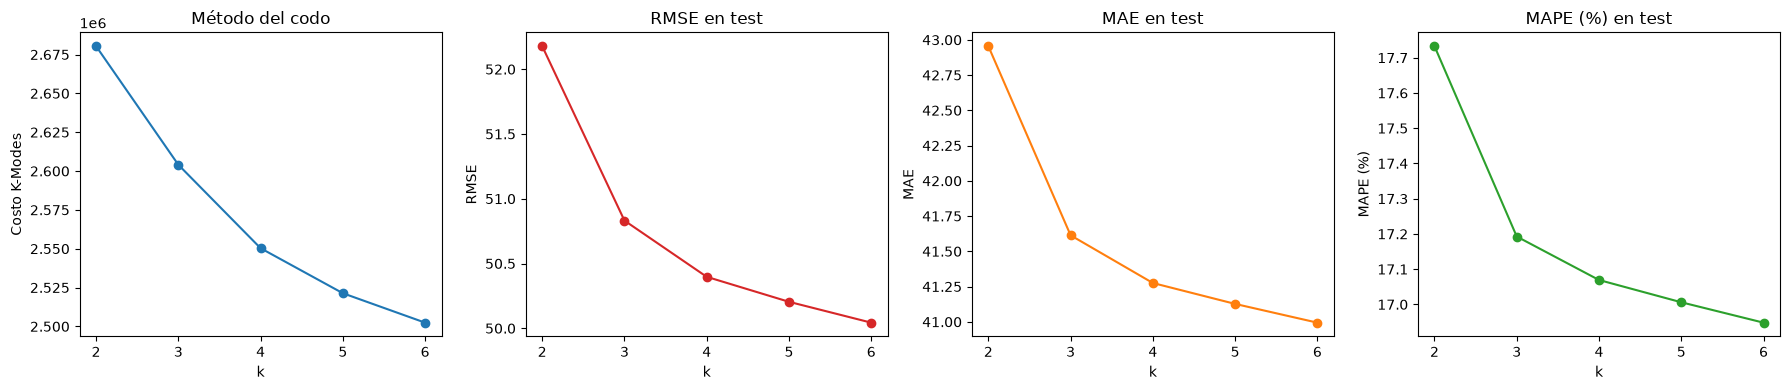

In [44]:
# ---------------------------------------------------------------
# 3. Elegir k (codo + métricas en test)
# ---------------------------------------------------------------
filas = []
for k in range(2, 7):
    m = KModesRegressor(n_clusters=k).fit(X_train, y_train)
    met = calcular_metricas(y_test, m.predict(X_test))
    filas.append({"k": k, "costo": m.costo, **met})
    print(
        f"k={k:2d} | RMSE={met['RMSE']:.2f} | MAE={met['MAE']:.2f} | "
        f"MAPE={met['MAPE (%)']:.2f}% | R2={met['R2']:.3f}"
    )
 
resultados = pd.DataFrame(filas)
 
fig, ax = plt.subplots(1, 4, figsize=(18, 4))
ax[0].plot(resultados["k"], resultados["costo"], marker="o")
ax[0].set(title="Método del codo", xlabel="k", ylabel="Costo K-Modes")
for a, col, c in zip(ax[1:], ["RMSE", "MAE", "MAPE (%)"], ["tab:red", "tab:orange", "tab:green"]):
    a.plot(resultados["k"], resultados[col], marker="o", color=c)
    a.set(title=f"{col} en test", xlabel="k", ylabel=col)
plt.tight_layout()
plt.show()

In [45]:
# ---------------------------------------------------------------
# 4. Modelo final (ajusta K_FINAL según las gráficas)
# ---------------------------------------------------------------
K_FINAL = 8
modelo = KModesRegressor(n_clusters=K_FINAL).fit(X_train, y_train)
 
met = evaluar(modelo, X_train, y_train, X_test, y_test)
print("\n=== Métricas del modelo final ===")
print(pd.DataFrame(met).round(3))
 
# Baseline: predecir siempre la media de train
base = calcular_metricas(y_test, np.full(len(y_test), y_train.mean()))
print("\n=== Baseline (predecir la media) en test ===")
print(pd.Series(base).round(3))
 
# Perfil de cada cluster
perfil = (
    pd.DataFrame({"cluster": modelo.labels_, "y": y_train.values})
    .groupby("cluster")["y"].agg(["count", "mean", "std"])
    .round(2)
)
print("\n=== Perfil de clusters ===\n", perfil)
 
# Categorías más frecuentes (centroides) de cada cluster
centros = pd.DataFrame(modelo.modelo_.cluster_centroids_, columns=X.columns)
print("\n=== Centroides (modas por cluster) ===\n", centros)
 


=== Métricas del modelo final ===
           train    test
RMSE      49.681  49.600
MAE       40.626  40.502
MAPE (%)  16.822  16.742
R2         0.107   0.106

=== Baseline (predecir la media) en test ===
RMSE        52.445
MAE         43.215
MAPE (%)    17.836
R2          -0.000
dtype: float64

=== Perfil de clusters ===
          count    mean    std
cluster                      
0        28724  259.40  50.79
1        16174  250.89  50.71
2        24263  254.29  47.73
3        21770  239.84  46.69
4        10331  253.84  50.20
5        16777  297.98  52.89
6         7609  247.86  49.80
7         9555  236.65  49.57

=== Centroides (modas por cluster) ===
   periodo cole_area_ubicacion     cole_caracter cole_jornada  \
0   20242              urbano  tecnicoacademico       manana   
1   20252              urbano  tecnicoacademico        unica   
2   20232              urbano  tecnicoacademico       manana   
3   20222              urbano  tecnicoacademico       manana   
4   20252    

# Random Forest

In [31]:
# ---------------------------------------------------------------
# 1. Métricas: RMSE, MAE, MAPE, R2
# ---------------------------------------------------------------
def calcular_metricas(y_real, y_pred):
    y_real = np.asarray(y_real)
    mask = y_real != 0  # MAPE no está definido si y_real = 0
    return {
        "RMSE": np.sqrt(mean_squared_error(y_real, y_pred)),
        "MAE": mean_absolute_error(y_real, y_pred),
        "MAPE (%)": mean_absolute_percentage_error(y_real[mask], np.asarray(y_pred)[mask]) * 100,
        "R2": r2_score(y_real, y_pred),
    }

In [32]:
# ---------------------------------------------------------------
# 2. Pipeline: One-Hot (categóricas) + Random Forest
#    min_frequency agrupa categorías muy raras para no inflar columnas
# ---------------------------------------------------------------
pipe = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=0.01)),
    ("rf", RandomForestRegressor(random_state=42, n_jobs=-1)),
])

In [ ]:
# ---------------------------------------------------------------
# 3. Búsqueda de hiperparámetros (rápida)
# ---------------------------------------------------------------
# One-Hot una sola vez (matriz dispersa) en vez de repetirlo en cada ajuste
enc = OneHotEncoder(handle_unknown="ignore", min_frequency=0.01)
X_train_enc = enc.fit_transform(X_train)

param_dist = {
    "max_depth": [10, 15, 20],
    "min_samples_leaf": [5, 10, 20],
    "max_features": ["sqrt", 0.3],
    "max_samples": [0.3, 0.5],      # cada árbol usa solo 30-50% de las filas
}

busqueda = RandomizedSearchCV(
    RandomForestRegressor(n_estimators=100, random_state=42),  # sin n_jobs aquí
    param_distributions=param_dist,
    n_iter=5,
    cv=2,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=-1,                       # paralelismo solo en la búsqueda
    verbose=1,
)
busqueda.fit(X_train_enc, y_train)

print("\nMejores hiperparámetros:", busqueda.best_params_)
print("MAE en validación cruzada:", round(-busqueda.best_score_, 3))

# Pipeline final con el encoder ya ajustado y el mejor bosque,
# así el resto del script (predict, importancias) funciona igual
modelo = Pipeline([("onehot", enc), ("rf", busqueda.best_estimator_)])

Fitting 2 folds for each of 5 candidates, totalling 10 fits


In [27]:
met = {
    "train": calcular_metricas(y_train, modelo.predict(X_train)),
    "test": calcular_metricas(y_test, modelo.predict(X_test)),
}
print("\n=== Métricas del modelo final ===")
print(pd.DataFrame(met).round(3))
 
# Baseline: predecir siempre la media de train
base = calcular_metricas(y_test, np.full(len(y_test), y_train.mean()))
print("\n=== Baseline (predecir la media) en test ===")
print(pd.Series(base).round(3))
 


=== Métricas del modelo final ===
           train    test
RMSE      23.989  24.625
MAE       18.211  18.587
MAPE (%)   7.656   7.804
R2         0.792   0.780

=== Baseline (predecir la media) en test ===
RMSE        52.445
MAE         43.215
MAPE (%)    17.836
R2          -0.000
dtype: float64



=== Importancia por variable ===
 variable
punt_c_naturales                 0.4818
punt_ingles                      0.1066
punt_lectura_critica             0.1039
punt_sociales_ciudadanas         0.0809
cole_jornada                     0.0474
fami_tienecomputador             0.0458
punt_matematicas                 0.0424
cole_mcpio_ubicacion             0.0190
cole_naturaleza                  0.0167
estu_mcpio_reside                0.0124
fami_numlibros                   0.0037
fami_educacionmadre              0.0025
fami_situacioneconomica          0.0024
estu_horassemanatrabaja          0.0024
fami_educacionpadre              0.0022
periodo                          0.0020
fami_tieneautomovil              0.0020
estu_dedicacioninternet          0.0020
estu_dedicacionlecturadiaria     0.0020
fami_cuartoshogar                0.0017
estu_genero                      0.0017
fami_tieneinternet               0.0016
fami_personashogar               0.0016
fami_comecerealfrutoslegumbre    0.0

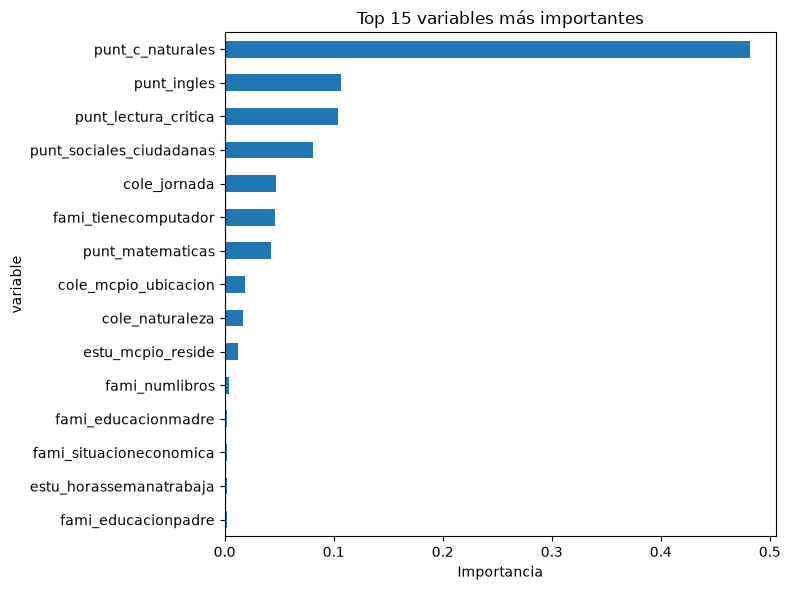

In [30]:
enc = modelo.named_steps["onehot"]
rf = modelo.named_steps["rf"]
nombres = enc.get_feature_names_out(X.columns)
 
 
def variable_original(nombre_dummy):
    # Busca la columna original más larga cuyo prefijo coincida
    candidatas = [c for c in X.columns if nombre_dummy.startswith(c + "_")]
    return max(candidatas, key=len) if candidatas else nombre_dummy
 
 
imp = (
    pd.DataFrame({"feature": nombres, "importancia": rf.feature_importances_})
    .assign(variable=lambda d: d["feature"].map(variable_original))
    .groupby("variable")["importancia"].sum()
    .sort_values(ascending=False)
)
print("\n=== Importancia por variable ===\n", imp.round(4))
 
imp.head(15).sort_values().plot(kind="barh", figsize=(8, 6), title="Top 15 variables más importantes")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()
 

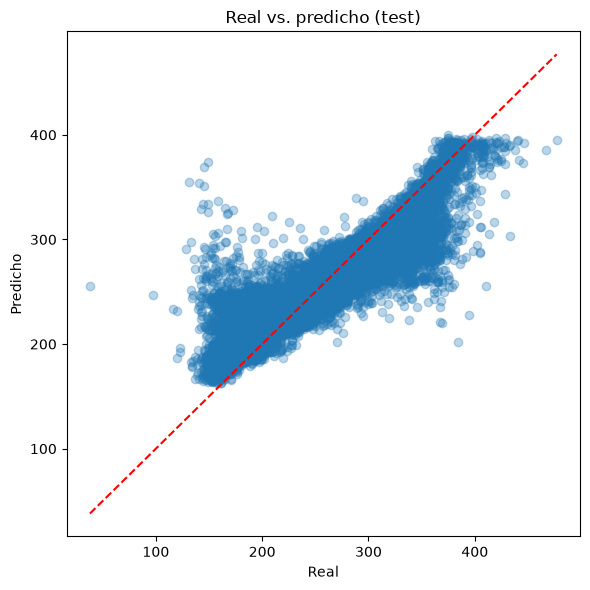

In [11]:
# ---------------------------------------------------------------
# 6. Real vs. predicho (test)
# ---------------------------------------------------------------
pred_test = modelo.predict(X_test)
plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred_test, alpha=0.3)
lim = [min(y_test.min(), pred_test.min()), max(y_test.max(), pred_test.max())]
plt.plot(lim, lim, "r--")
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.title("Real vs. predicho (test)")
plt.tight_layout()
plt.show()

# XgBoost Regression 

In [13]:
# ---------------------------------------------------------------
# 0. Datos (df ya cargado)
# ---------------------------------------------------------------
df = df.dropna(subset=['punt_global']).copy()          # sin nulos en el objetivo
 
y = df['punt_global']
X = df.drop(columns=['punt_global']).fillna('Sin dato').astype(str)
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
# ---------------------------------------------------------------
# 1. Categóricas nativas de XGBoost (sin One-Hot: más rápido y liviano)
#    Las categorías se definen con TRAIN; las nuevas en test pasan a NaN,
#    que XGBoost maneja sin problema.
# ---------------------------------------------------------------
categorias = {c: X_train[c].astype("category").cat.categories for c in X.columns}
 
 
def a_categorico(Xd):
    Xc = Xd.copy()
    for c in Xc.columns:
        Xc[c] = pd.Categorical(Xc[c], categories=categorias[c])
    return Xc
 
 
X_train_c = a_categorico(X_train)
X_test_c = a_categorico(X_test)
 

C:\Users\ruizt\AppData\Local\Temp\ipykernel_20268\2192364393.py:12: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  Xc[c] = pd.Categorical(Xc[c], categories=categorias[c])


In [15]:
# ---------------------------------------------------------------
# 2. Métricas: RMSE, MAE, MAPE, R2
# ---------------------------------------------------------------
def calcular_metricas(y_real, y_pred):
    y_real = np.asarray(y_real)
    y_pred = np.asarray(y_pred)
    mask = y_real != 0  # MAPE no está definido si y_real = 0
    return {
        "RMSE": np.sqrt(mean_squared_error(y_real, y_pred)),
        "MAE": mean_absolute_error(y_real, y_pred),
        "MAPE (%)": mean_absolute_percentage_error(y_real[mask], y_pred[mask]) * 100,
        "R2": r2_score(y_real, y_pred),
    }
 

In [16]:
# ---------------------------------------------------------------
# 3. Búsqueda de hiperparámetros (rápida, validación cruzada sobre TRAIN)
#    Learning rate alto y pocos árboles solo para explorar;
#    el modelo final usa learning rate bajo + early stopping.
# ---------------------------------------------------------------
param_dist = {
    "max_depth": [3, 4, 6, 8],
    "min_child_weight": [1, 5, 10],
    "subsample": [0.7, 0.9, 1.0],
    "colsample_bytree": [0.5, 0.8, 1.0],
    "reg_lambda": [1, 5, 10],
}
 
busqueda = RandomizedSearchCV(
    XGBRegressor(
        tree_method="hist",
        enable_categorical=True,
        n_estimators=200,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1,          # XGBoost ya paraleliza internamente
    ),
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=1,               # evita saturar el CPU con doble paralelismo
    verbose=1,
)
busqueda.fit(X_train_c, y_train)
 
print("\nMejores hiperparámetros:", busqueda.best_params_)
print("MAE en validación cruzada:", round(-busqueda.best_score_, 3))
 
 

Fitting 3 folds for each of 10 candidates, totalling 30 fits

Mejores hiperparámetros: {'subsample': 0.7, 'reg_lambda': 1, 'min_child_weight': 10, 'max_depth': 6, 'colsample_bytree': 0.8}
MAE en validación cruzada: 1.029


In [17]:
# ---------------------------------------------------------------
# 4. Modelo final: learning rate bajo + early stopping
#    (se reserva 15% de train como validación para frenar a tiempo)
# ---------------------------------------------------------------
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_c, y_train, test_size=0.15, random_state=42
)
 
modelo = XGBRegressor(
    tree_method="hist",
    enable_categorical=True,
    n_estimators=2000,          # tope; early stopping decide cuántos usar
    learning_rate=0.05,
    early_stopping_rounds=50,
    eval_metric="mae",
    random_state=42,
    n_jobs=-1,
    **busqueda.best_params_,
)
modelo.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
 
print("\nÁrboles usados (best_iteration):", modelo.best_iteration + 1)
 
 


Árboles usados (best_iteration): 2000


In [18]:
# ---------------------------------------------------------------
# 5. Evaluación en train y test
# ---------------------------------------------------------------
met = {
    "train": calcular_metricas(y_train, modelo.predict(X_train_c)),
    "test": calcular_metricas(y_test, modelo.predict(X_test_c)),
}
print("\n=== Métricas del modelo final ===")
print(pd.DataFrame(met).round(3))
 
# Baseline: predecir siempre la media de train
base = calcular_metricas(y_test, np.full(len(y_test), y_train.mean()))
print("\n=== Baseline (predecir la media) en test ===")
print(pd.Series(base).round(3))
 
 


=== Métricas del modelo final ===
          train   test
RMSE      0.565  1.183
MAE       0.351  0.687
MAPE (%)  0.142  0.279
R2        1.000  0.999

=== Baseline (predecir la media) en test ===
RMSE        52.445
MAE         43.215
MAPE (%)    17.836
R2          -0.000
dtype: float64



=== Importancia por variable ===
 punt_sociales_ciudadanas         0.4031
punt_c_naturales                 0.3634
punt_matematicas                 0.1234
punt_lectura_critica             0.0972
punt_ingles                      0.0086
estu_genero                      0.0026
periodo                          0.0002
cole_area_ubicacion              0.0001
fami_tienemotocicleta            0.0001
cole_mcpio_ubicacion             0.0001
estu_mcpio_reside                0.0001
cole_caracter                    0.0001
fami_numlibros                   0.0001
fami_tienecomputador             0.0001
estu_dedicacioninternet          0.0001
fami_trabajolaborpadre           0.0001
fami_estratovivienda             0.0001
fami_educacionpadre              0.0001
cole_naturaleza                  0.0000
fami_trabajolabormadre           0.0000
fami_educacionmadre              0.0000
cole_jornada                     0.0000
fami_comecarnepescadohuevo       0.0000
estu_horassemanatrabaja          0.0000
estu_

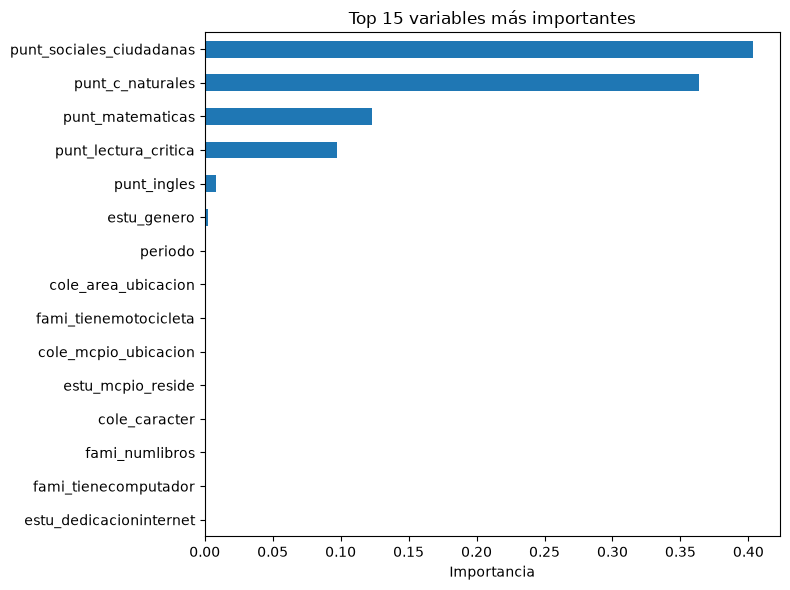

In [19]:
# ---------------------------------------------------------------
# 6. Importancia de variables (ya viene por variable original)
# ---------------------------------------------------------------
imp = (
    pd.Series(modelo.feature_importances_, index=X.columns)
    .sort_values(ascending=False)
)
print("\n=== Importancia por variable ===\n", imp.round(4))
 
imp.head(15).sort_values().plot(kind="barh", figsize=(8, 6), title="Top 15 variables más importantes")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()
 

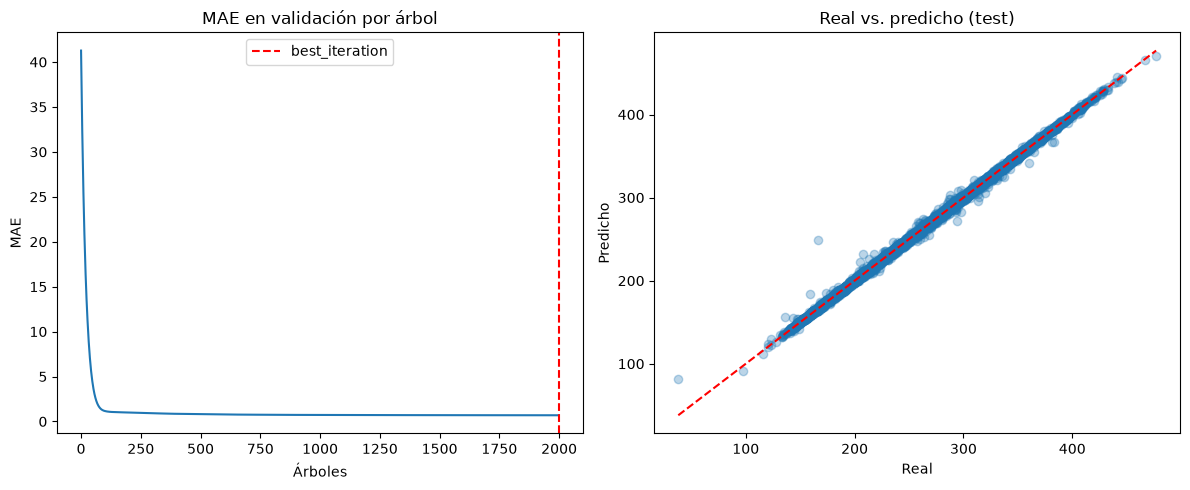

In [20]:
# ---------------------------------------------------------------
# 7. Curva de aprendizaje y real vs. predicho
# ---------------------------------------------------------------
curva = modelo.evals_result()["validation_0"]["mae"]
pred_test = modelo.predict(X_test_c)
 
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(curva)
ax[0].axvline(modelo.best_iteration, color="r", linestyle="--", label="best_iteration")
ax[0].set(title="MAE en validación por árbol", xlabel="Árboles", ylabel="MAE")
ax[0].legend()
 
ax[1].scatter(y_test, pred_test, alpha=0.3)
lim = [min(y_test.min(), pred_test.min()), max(y_test.max(), pred_test.max())]
ax[1].plot(lim, lim, "r--")
ax[1].set(title="Real vs. predicho (test)", xlabel="Real", ylabel="Predicho")
plt.tight_layout()
plt.show()